In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv('data/Popular_Spotify_Songs.csv', encoding='latin1')
df

In [3]:

df = df.drop_duplicates()

df['released_year'] = df['released_year'].astype(int)
df['released_month'] = df['released_month'].astype(int)
df['released_day'] = df['released_day'].astype(int)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [4]:

cols_to_fix = ['streams', 'in_deezer_playlists', 'in_shazam_charts']

for col in cols_to_fix:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(',', '')
        .str.replace(' ', '')
        .str.replace('-', '0')
    )

    df[col] = pd.to_numeric(df[col], errors='coerce')

df['key'] = df['key'].fillna('Unknown')
df[cols_to_fix] = df[cols_to_fix].fillna(0)

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    object 
 1   artist(s)_name        953 non-null    object 
 2   artist_count          953 non-null    int64  
 3   released_year         953 non-null    int64  
 4   released_month        953 non-null    int64  
 5   released_day          953 non-null    int64  
 6   in_spotify_playlists  953 non-null    int64  
 7   in_spotify_charts     953 non-null    int64  
 8   streams               953 non-null    float64
 9   in_apple_playlists    953 non-null    int64  
 10  in_apple_charts       953 non-null    int64  
 11  in_deezer_playlists   953 non-null    int64  
 12  in_deezer_charts      953 non-null    int64  
 13  in_shazam_charts      953 non-null    float64
 14  bpm                   953 non-null    int64  
 15  key                   9

In [5]:
df['log_streams'] = np.log1p(df['streams'])
df[['streams', 'log_streams']].head()


,streams,log_streams
0,141381703.0,18.766974
1,133716286.0,18.711231
2,140003974.0,18.757181
3,800840817.0,20.501173
4,303236322.0,19.530023


In [6]:
numeric_features = [
    'released_year', 'released_month', 'released_day',
    'artist_count',
    'in_spotify_playlists', 'in_spotify_charts',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts',
    'danceability_%', 'valence_%', 'energy_%',
    'acousticness_%', 'instrumentalness_%',
    'liveness_%', 'speechiness_%',
    'bpm'
]

categorical_features = ['key', 'mode']

X = df[numeric_features + categorical_features]
y = df['log_streams']


In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_r2 = r2_score(y_test, lr_pred)

print("Linear Regression Results:")
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)
print("R²:", lr_r2)

Linear Regression Results:
RMSE: 0.7304008470243993
MAE: 0.579620887897714
R²: 0.4715387918765379


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        max_depth=None,
        min_samples_split=2
    ))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results:")
print("RMSE:", rf_rmse)
print("MAE:", rf_mae)
print("R²:", rf_r2)


Random Forest Results:
RMSE: 0.4525523963051533
MAE: 0.35158594342921307
R²: 0.797125101909351


In [11]:
from sklearn.svm import SVR

svr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", SVR(kernel='rbf', C=10, gamma='scale'))
])

svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)

svr_rmse = np.sqrt(mean_squared_error(y_test, svr_pred))
svr_mae = mean_absolute_error(y_test, svr_pred)
svr_r2 = r2_score(y_test, svr_pred)

print("SVR Results:")
print("RMSE:", svr_rmse)
print("MAE:", svr_mae)
print("R²:", svr_r2)


SVR Results:
RMSE: 0.6429453024337834
MAE: 0.5170617814996932
R²: 0.5905144017375348


In [12]:
from sklearn.tree import DecisionTreeRegressor

dt_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(
        max_depth=None,
        random_state=42
    ))
])

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_r2 = r2_score(y_test, dt_pred)

print("Decision Tree:")
print(dt_rmse, dt_mae, dt_r2)


Decision Tree:
0.5635351064244134 0.4369497289103122 0.685418970267392


In [13]:
from xgboost import XGBRegressor

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost:")
print(xgb_rmse, xgb_mae, xgb_r2)


XGBoost:
0.7474255515136138 0.41990011485262363 0.4466161785570645


In [14]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression

kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_cv_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

cv_rmse = -cross_val_score(
    lr_cv_model, X, y,
    scoring="neg_root_mean_squared_error",
    cv=kf
)

print("CV RMSE Scores:", cv_rmse)
print("Mean CV RMSE:", cv_rmse.mean())


CV RMSE Scores: [0.73040085 0.77579218 0.90530411 1.08366031 1.59850879]
Mean CV RMSE: 1.0187332490640941


In [15]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
ridge_pred = ridge_model.predict(X_test)

print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Ridge R2:", r2_score(y_test, ridge_pred))


Ridge RMSE: 0.7298642590200061
Ridge R2: 0.47231497329951966


In [16]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Lasso(alpha=0.001, max_iter=5000))
])

lasso_model.fit(X_train, y_train)
lasso_pred = lasso_model.predict(X_test)

print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("Lasso R2:", r2_score(y_test, lasso_pred))


Lasso RMSE: 0.7264756175823078
Lasso R2: 0.4772035106246708


In [17]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = df[numeric_features].astype(float)

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i)
                   for i in range(X_vif.shape[1])]

vif_data


,feature,VIF
0,released_year,99.552623
1,released_month,4.128124
2,released_day,3.416574
3,artist_count,4.395215
4,in_spotify_playlists,8.287183
5,in_spotify_charts,3.212234
6,in_apple_playlists,4.648018
7,in_apple_charts,3.555474
8,in_deezer_playlists,3.924573
9,in_deezer_charts,2.202701


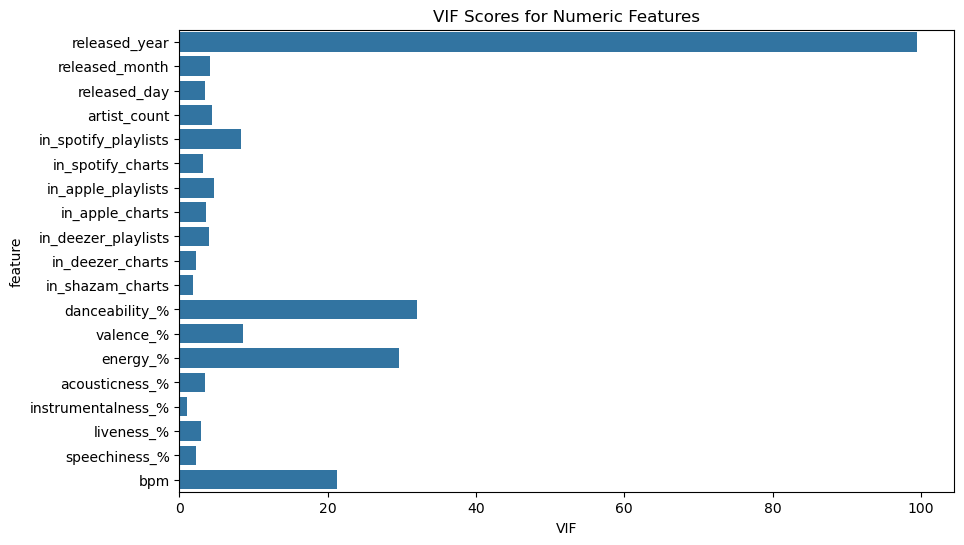

In [18]:
plt.figure(figsize=(10,6))
sns.barplot(data=vif_data, x="VIF", y="feature")
plt.title("VIF Scores for Numeric Features")
plt.show()



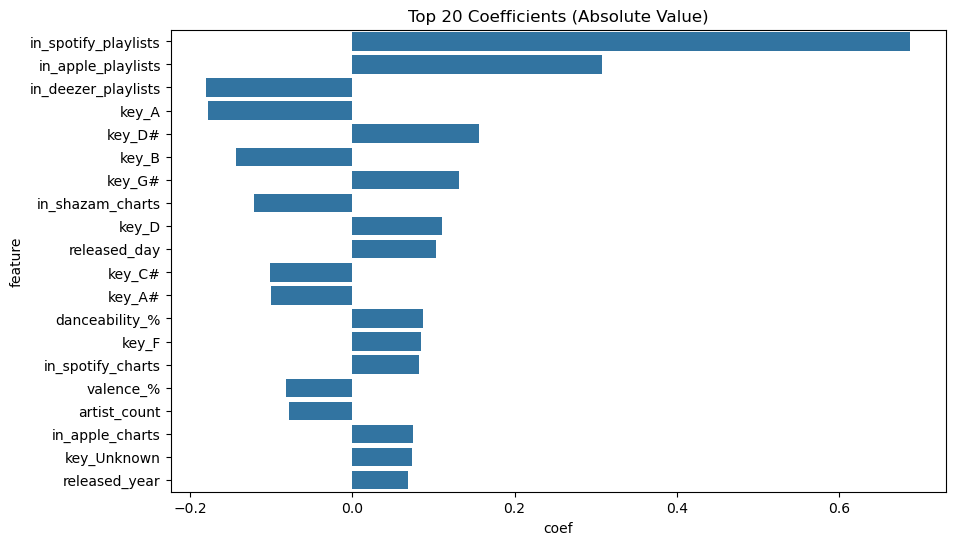

In [19]:
lin = lr_model.named_steps["regressor"]
enc = lr_model.named_steps["preprocessor"].named_transformers_["cat"]
ohe_features = enc.get_feature_names_out(categorical_features)

all_features = numeric_features + list(ohe_features)
coef = lin.coef_

coef_df = pd.DataFrame({"feature": all_features, "coef": coef})
coef_df = coef_df.sort_values("coef", key=abs, ascending=False).head(20)

plt.figure(figsize=(10,6))
sns.barplot(data=coef_df, x="coef", y="feature")
plt.title("Top 20 Coefficients (Absolute Value)")
plt.show()


In [20]:
df = df.drop(columns=['released_year'])
numeric_features.remove('released_year')


In [21]:
linear_numeric_features = [
    'released_month', 'released_day',
    'artist_count',
    'in_spotify_playlists', 'in_spotify_charts',
    'in_apple_playlists', 'in_apple_charts',
    'in_deezer_playlists', 'in_deezer_charts',
    'in_shazam_charts',
    'valence_%',
    'acousticness_%', 'instrumentalness_%', 'liveness_%',
    'speechiness_%',
]


In [22]:
linear_categorical_features = ['key', 'mode']


In [23]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), linear_numeric_features),
        ("cat", OneHotEncoder(handle_unknown='ignore'), linear_categorical_features)
    ]
)


In [24]:
nonlinear_preprocessor = preprocessor


In [25]:
lr_model = Pipeline(steps=[
    ("preprocessor", linear_preprocessor),
    ("regressor", LinearRegression())
])
lr_model.fit(X_train[linear_numeric_features + linear_categorical_features], y_train)
lr_pred = lr_model.predict(X_test[linear_numeric_features + linear_categorical_features])


In [26]:
from sklearn.linear_model import ElasticNet
elastic_model = Pipeline(steps=[
    ("preprocessor", linear_preprocessor),
    ("regressor", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000))
])
elastic_model.fit(X_train[linear_numeric_features + linear_categorical_features], y_train)
elastic_pred = elastic_model.predict(X_test[linear_numeric_features + linear_categorical_features])


In [27]:
rf_model = Pipeline(steps=[
    ("preprocessor", nonlinear_preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=500, random_state=19))
])
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)


In [28]:
svr_model = Pipeline(steps=[
    ("preprocessor", nonlinear_preprocessor),
    ("regressor", SVR(kernel='rbf', C=10, gamma='scale'))
])
svr_model.fit(X_train, y_train)
svr_pred = svr_model.predict(X_test)


In [29]:
results = pd.DataFrame([
    ["Linear Regression",
     np.sqrt(mean_squared_error(y_test, lr_pred)),
     mean_absolute_error(y_test, lr_pred),
     r2_score(y_test, lr_pred)],

    ["Elastic Net",
     np.sqrt(mean_squared_error(y_test, elastic_pred)),
     mean_absolute_error(y_test, elastic_pred),
     r2_score(y_test, elastic_pred)],

    ["Random Forest",
     np.sqrt(mean_squared_error(y_test, rf_pred)),
     mean_absolute_error(y_test, rf_pred),
     r2_score(y_test, rf_pred)],

    ["SVR",
     np.sqrt(mean_squared_error(y_test, svr_pred)),
     mean_absolute_error(y_test, svr_pred),
     r2_score(y_test, svr_pred)]
], columns=["Model", "RMSE", "MAE", "R²"])

results.sort_values("RMSE")


,Model,RMSE,MAE,R²
2,Random Forest,0.515904,0.403071,0.736349
3,SVR,0.662598,0.528686,0.565098
1,Elastic Net,0.718539,0.588660,0.488563
0,Linear Regression,0.722747,0.577396,0.482557


In [30]:
param_grid_rf_fast = {
    "regressor__n_estimators": [200, 400],
    "regressor__max_depth": [15, None],
    "regressor__min_samples_split": [2, 10]
}


In [31]:
kf = KFold(n_splits=3, shuffle=True, random_state=42)

In [32]:
df_small = df.sample(frac=0.6, random_state =42)
X_small = df_small.drop("log_streams", axis=1)
y_small = df_small["log_streams"]


In [33]:
X_encoded = nonlinear_preprocessor.fit_transform(X)


In [34]:
from sklearn.model_selection import GridSearchCV, KFold

param_grid_rf_fast = {
    "regressor__n_estimators": [200, 400],
    "regressor__max_depth": [15,    None],
    "regressor__min_samples_split": [2, 10]
}

kf = KFold(n_splits=3, shuffle=True, random_state=42)

rf_pipeline = Pipeline(steps=[
    ("preprocessor", nonlinear_preprocessor),
    ("regressor", RandomForestRegressor(random_state=42))
])

rf_grid = GridSearchCV(
    rf_pipeline,
    param_grid_rf_fast,
    scoring="neg_root_mean_squared_error",
    cv=kf,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

rf_pred = best_rf.predict(X_test)

print("Best params:", rf_grid.best_params_)
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2:", r2_score(y_test, rf_pred))


Best params: {'regressor__max_depth': 15, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 200}
RMSE: 0.5156892971492754
R2: 0.7365690410209493


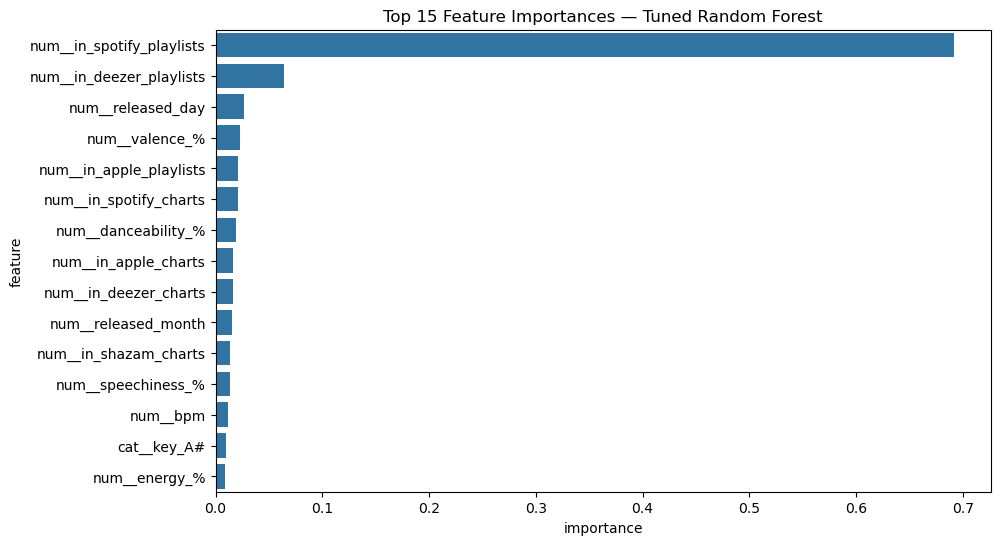

In [35]:
rf_reg = best_rf.named_steps["regressor"]
importances = rf_reg.feature_importances_

feat_names = best_rf.named_steps["preprocessor"].get_feature_names_out()

imp_df = pd.DataFrame({"feature": feat_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=imp_df.head(15), x="importance", y="feature")
plt.title("Top 15 Feature Importances — Tuned Random Forest")
plt.show()


Text(0, 0.5, 'Residuals')

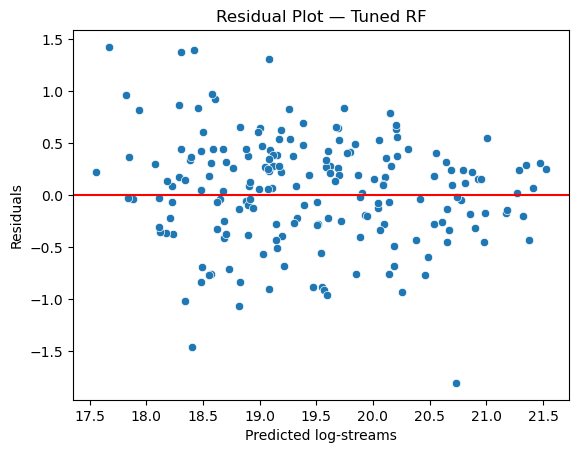

In [36]:
pred = best_rf.predict(X_test)
resid = y_test - pred

sns.scatterplot(x=pred, y=resid)
plt.axhline(0, color='red')
plt.title("Residual Plot — Tuned RF")
plt.xlabel("Predicted log-streams")
plt.ylabel("Residuals")


In [37]:

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df.drop(columns=["log_streams"]),
    df["log_streams"],
    test_size=0.2,
    random_state=42
)

pred = best_rf.predict(X_test)

df_test = X_test_raw.copy()
df_test["true"] = y_test
df_test["pred"] = pred
df_test["error"] = abs(df_test["true"] - df_test["pred"])

df_test["is_taylor"] = df_test["artist(s)_name"].str.contains("Taylor Swift", case=False)

df_test.groupby("is_taylor")["error"].mean()


is_taylor
False    0.410076
True     0.260599
Name: error, dtype: float64

In [38]:
artist_counts = df['artist(s)_name'].value_counts()
major_artists = artist_counts[artist_counts >= 5].index.tolist()

major_artists


['Taylor Swift',
 'The Weeknd',
 'Bad Bunny',
 'SZA',
 'Harry Styles',
 'Kendrick Lamar',
 'Morgan Wallen',
 'Ed Sheeran',
 'Feid',
 'Drake, 21 Savage',
 'BTS',
 'Labrinth',
 'Olivia Rodrigo',
 'Doja Cat',
 'NewJeans',
 'Billie Eilish']

In [39]:
major_artists = [
 'Taylor Swift',
 'The Weeknd',
 'SZA',
 'Bad Bunny',
 'Harry Styles',
 'Kendrick Lamar',
 'Morgan Wallen',
 'Ed Sheeran',
 'BTS',
 'Feid',
 'Drake, 21 Savage',
 'Olivia Rodrigo',
 'Labrinth',
 'Doja Cat',
 'NewJeans',
 'Billie Eilish'
]


In [40]:
df_test = X_test_raw.copy()
df_test["true"] = y_test
df_test["pred"] = best_rf.predict(X_test)
df_test["error"] = abs(df_test["true"] - df_test["pred"])

def clean_name(name):
    return name.replace(" ", "_").replace(",", "").replace(".", "")

for artist in major_artists:
    cleaned = clean_name(artist)
    df_test[f"is_{cleaned}"] = df_test["artist(s)_name"].str.contains(artist, case=False)


In [41]:
artist_errors = {}

for artist in major_artists:
    mask = df_test["artist(s)_name"].str.contains(artist, case=False)

    if mask.sum() == 0:
        continue

    mae = df_test.loc[mask, "error"].mean()
    artist_errors[artist] = mae

artist_errors_df = (
    pd.DataFrame.from_dict(artist_errors, orient="index", columns=["MAE"])
    .sort_values("MAE")
)

artist_errors_df


,MAE
Feid,0.097533
Morgan Wallen,0.124351
"Drake, 21 Savage",0.183355
Taylor Swift,0.260599
The Weeknd,0.280057
Doja Cat,0.379183
Harry Styles,0.390622
SZA,0.391837
BTS,0.433058
Bad Bunny,0.433923


C:\Users\matth\AppData\Local\Temp\ipykernel_23556\3679194050.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


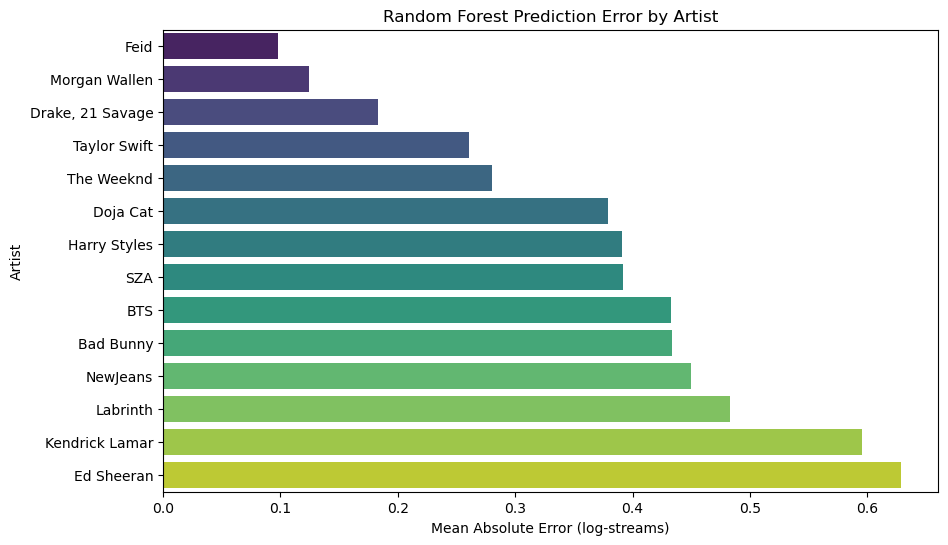

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=artist_errors_df.reset_index(),
    x="MAE",
    y="index",
    palette="viridis"
)
plt.xlabel("Mean Absolute Error (log-streams)")
plt.ylabel("Artist")
plt.title("Random Forest Prediction Error by Artist")
plt.show()


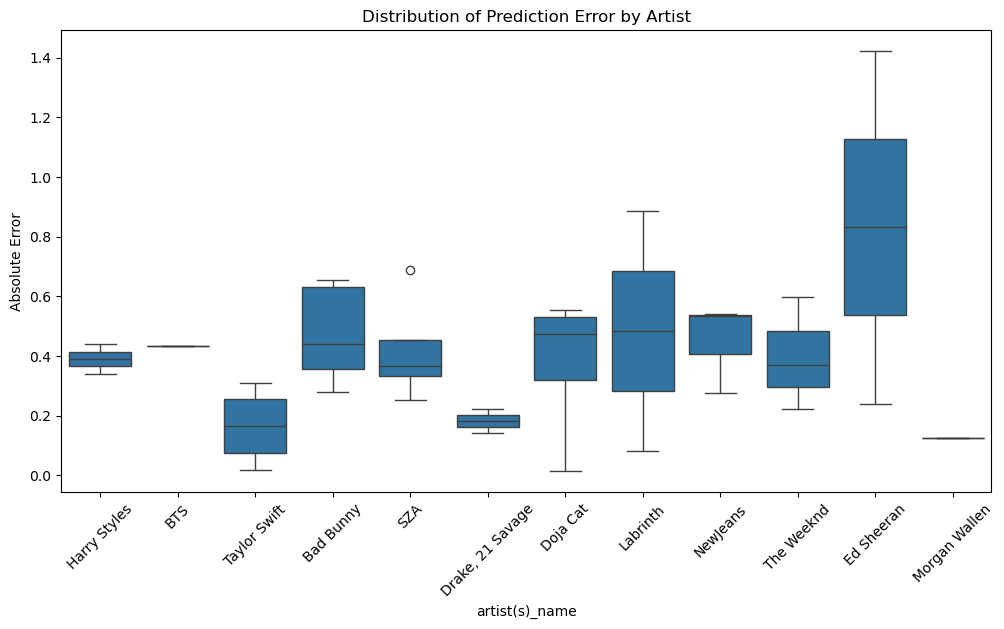

In [43]:
selected = artist_errors_df.index.tolist()

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_test[df_test["artist(s)_name"].isin(selected)],
    x="artist(s)_name",
    y="error"
)
plt.xticks(rotation=45)
plt.title("Distribution of Prediction Error by Artist")
plt.ylabel("Absolute Error")
plt.show()
